In [1]:
import os
import sys

if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

from tqdm import tqdm
import logging 
logging.getLogger('pgmpy').setLevel(logging.WARNING)
logging.getLogger('pySOT').setLevel(logging.WARNING)


import warnings 
warnings.filterwarnings("ignore")
import pandas as pd


## Datasets

In [33]:
from utils.data import load_csv_with_attrs



df = load_csv_with_attrs("data/datasets/jpmf_data/Data_Graph_160.csv")
print("Data Attributes:", df.attrs)

df = load_csv_with_attrs("data/datasets/jpmf_data/Data_Graph_600.csv")
print("Data Attributes:", df.attrs)

df = load_csv_with_attrs("data/datasets/jpmf_data/Data_Graph_350.csv")
print("Data Attributes:", df.attrs)

Data Attributes: {'i': 160, 'family': 'er', 'target_mi': 0.31699250014423125, 'pair_probs': 0.4, 'syn_cutoff': 0.4, 'num_vars': 30}
Data Attributes: {'i': 600, 'family': 'small-world', 'target_mi': 0.31699250014423125, 'pair_probs': 0.4, 'syn_cutoff': 0.6, 'num_vars': 20}
Data Attributes: {'i': 350, 'family': 'ba', 'target_mi': 0.6339850002884625, 'pair_probs': 0.6, 'syn_cutoff': 0.5, 'num_vars': 20}


In [2]:
import pandas as pd, os, json, numpy as np, textwrap, math
base='results/param_sweeps/'
files=[f for f in os.listdir(base) if f.endswith('.csv')]
files


['sweep_agg_ba.csv',
 'sweep_agg_er.csv',
 'sweep_agg_ws.csv',
 'sweep_trials_ba.csv',
 'sweep_trials_er.csv',
 'sweep_trials_ws.csv']

In [3]:
agg={}
for fam in ['er','ba','ws']:
    df=pd.read_csv(f'results/param_sweeps/sweep_agg_{fam}.csv').copy()
    # rank descending by mean
    df['rank_'+fam]=df['mean'].rank(ascending=False, method='min')
    # z-score on mean
    df['z_'+fam]=(df['mean']-df['mean'].mean())/df['mean'].std(ddof=0)
    agg[fam]=df
keys=['crossover_proportion','crossover_edges','mutation_prob','elitism_proportion']
merged=agg['er'][keys+['mean','std','rank_er','z_er']].rename(columns={'mean':'mean_er','std':'std_er'})
for fam in ['ba','ws']:
    merged=merged.merge(agg[fam][keys+['mean','std','rank_'+fam,'z_'+fam]].rename(columns={'mean':f'mean_{fam}','std':f'std_{fam}'}),on=keys)
merged['avg_rank']=merged[['rank_er','rank_ba','rank_ws']].mean(axis=1)
merged['max_rank']=merged[['rank_er','rank_ba','rank_ws']].max(axis=1)
merged['sum_z']=merged[['z_er','z_ba','z_ws']].sum(axis=1)
merged.sort_values('avg_rank').head(10)


,crossover_proportion,crossover_edges,mutation_prob,elitism_proportion,mean_er,std_er,rank_er,z_er,mean_ba,std_ba,rank_ba,z_ba,mean_ws,std_ws,rank_ws,z_ws,avg_rank,max_rank,sum_z
2,0.2,3,1.0,0.2,-115010.472520,2375.041073,3.0,2.599850,-60285.580862,2090.941073,1.0,2.057953,-73349.105943,1507.855077,6.0,2.209444,3.333333,6.0,6.867247
0,0.3,1,1.0,0.1,-113997.562069,1446.664058,1.0,3.074448,-60776.841999,866.600855,6.0,1.791924,-73417.795181,2742.851873,7.0,2.174875,4.666667,7.0,7.041247
13,0.2,1,1.0,0.1,-116253.958781,2086.900292,14.0,2.017215,-60707.730731,412.592835,5.0,1.829350,-73101.514502,1563.691837,5.0,2.334052,8.000000,14.0,6.180617
17,0.2,3,1.0,0.1,-116504.026546,1752.954533,18.0,1.900046,-60966.107477,2359.659625,13.0,1.689433,-73948.438095,654.381229,12.0,1.907814,14.333333,18.0,5.497293
7,0.2,5,0.9,0.1,-115831.010095,2527.493562,8.0,2.215388,-61163.940467,820.991519,25.0,1.582302,-74186.500403,1992.868999,18.0,1.788003,17.000000,25.0,5.585692
6,0.3,3,1.0,0.1,-115673.600299,1567.512619,7.0,2.289142,-61081.837262,2081.710059,19.0,1.626763,-74513.723419,1450.647339,27.0,1.623319,17.666667,27.0,5.539223
35,0.2,4,1.0,0.2,-117062.373877,2519.473929,36.0,1.638433,-61043.530060,933.404539,17.0,1.647507,-73723.704039,1458.820005,9.0,2.020918,20.666667,36.0,5.306858
1,0.2,2,1.0,0.1,-114737.375738,834.432997,2.0,2.727809,-61491.872638,1359.950742,46.0,1.404720,-74086.032303,2146.287491,15.0,1.838566,21.000000,46.0,5.971095
8,0.2,2,0.9,0.1,-116075.169591,2286.540900,9.0,2.100987,-61362.120817,2154.551924,38.0,1.474983,-74217.971657,2035.452787,19.0,1.772164,22.000000,38.0,5.348134
5,0.3,1,0.9,0.1,-115324.627443,1700.614630,6.0,2.452653,-61258.174850,1998.818367,32.0,1.531272,-74828.889685,1962.156430,38.0,1.464702,25.333333,38.0,5.448628


In [4]:
merged.sort_values('sum_z', ascending=False).head(10)

,crossover_proportion,crossover_edges,mutation_prob,elitism_proportion,mean_er,std_er,rank_er,z_er,mean_ba,std_ba,rank_ba,z_ba,mean_ws,std_ws,rank_ws,z_ws,avg_rank,max_rank,sum_z
0,0.3,1,1.0,0.1,-113997.562069,1446.664058,1.0,3.074448,-60776.841999,866.600855,6.0,1.791924,-73417.795181,2742.851873,7.0,2.174875,4.666667,7.0,7.041247
2,0.2,3,1.0,0.2,-115010.472520,2375.041073,3.0,2.599850,-60285.580862,2090.941073,1.0,2.057953,-73349.105943,1507.855077,6.0,2.209444,3.333333,6.0,6.867247
13,0.2,1,1.0,0.1,-116253.958781,2086.900292,14.0,2.017215,-60707.730731,412.592835,5.0,1.829350,-73101.514502,1563.691837,5.0,2.334052,8.000000,14.0,6.180617
1,0.2,2,1.0,0.1,-114737.375738,834.432997,2.0,2.727809,-61491.872638,1359.950742,46.0,1.404720,-74086.032303,2146.287491,15.0,1.838566,21.000000,46.0,5.971095
7,0.2,5,0.9,0.1,-115831.010095,2527.493562,8.0,2.215388,-61163.940467,820.991519,25.0,1.582302,-74186.500403,1992.868999,18.0,1.788003,17.000000,25.0,5.585692
6,0.3,3,1.0,0.1,-115673.600299,1567.512619,7.0,2.289142,-61081.837262,2081.710059,19.0,1.626763,-74513.723419,1450.647339,27.0,1.623319,17.666667,27.0,5.539223
17,0.2,3,1.0,0.1,-116504.026546,1752.954533,18.0,1.900046,-60966.107477,2359.659625,13.0,1.689433,-73948.438095,654.381229,12.0,1.907814,14.333333,18.0,5.497293
5,0.3,1,0.9,0.1,-115324.627443,1700.614630,6.0,2.452653,-61258.174850,1998.818367,32.0,1.531272,-74828.889685,1962.156430,38.0,1.464702,25.333333,38.0,5.448628
79,0.3,2,1.0,0.1,-117887.738643,2326.810399,80.0,1.251709,-60983.428536,730.423186,15.0,1.680053,-72898.073097,1184.473254,4.0,2.436439,33.000000,80.0,5.368202
8,0.2,2,0.9,0.1,-116075.169591,2286.540900,9.0,2.100987,-61362.120817,2154.551924,38.0,1.474983,-74217.971657,2035.452787,19.0,1.772164,22.000000,38.0,5.348134


In [5]:
## Heatmaps

In [6]:
import pandas as pd, numpy as np, os
# base='/mnt/data'
keys=['crossover_proportion','crossover_edges','mutation_prob','elitism_proportion']
families=['er','ba','ws']
merged=None
tops={}
for fam in families:
    df=pd.read_csv(f'{base}/sweep_agg_{fam}.csv').copy()
    df['rank']=df['mean'].rank(ascending=False, method='min')
    df['z']=(df['mean']-df['mean'].mean())/df['mean'].std(ddof=0)
    tops[fam]=df.sort_values('mean', ascending=False).head(10)
    tmp=df[keys+['mean','std','rank','z']].rename(columns={'mean':f'mean_{fam}','std':f'std_{fam}','rank':f'rank_{fam}','z':f'z_{fam}'})
    merged = tmp if merged is None else merged.merge(tmp,on=keys)
merged['avg_rank']=merged[[f'rank_{fam}' for fam in families]].mean(axis=1)
merged['median_rank']=merged[[f'rank_{fam}' for fam in families]].median(axis=1)
merged['max_rank']=merged[[f'rank_{fam}' for fam in families]].max(axis=1)
merged['sum_z']=merged[[f'z_{fam}' for fam in families]].sum(axis=1)
merged['avg_z']=merged[[f'z_{fam}' for fam in families]].mean(axis=1)
print("Best by avg_rank")
print(merged.sort_values(['avg_rank','max_rank','sum_z'], ascending=[True,True,False]).head(10).to_string(index=False))
print("Best by sum_z")
print(merged.sort_values(['sum_z','avg_rank'], ascending=[False,True]).head(10).to_string(index=False))


Best by avg_rank
 crossover_proportion  crossover_edges  mutation_prob  elitism_proportion        mean_er      std_er  rank_er     z_er       mean_ba      std_ba  rank_ba     z_ba       mean_ws      std_ws  rank_ws     z_ws  avg_rank  median_rank  max_rank    sum_z    avg_z
                  0.2                3            1.0                 0.2 -115010.472520 2375.041073      3.0 2.599850 -60285.580862 2090.941073      1.0 2.057953 -73349.105943 1507.855077      6.0 2.209444  3.333333          3.0       6.0 6.867247 2.289082
                  0.3                1            1.0                 0.1 -113997.562069 1446.664058      1.0 3.074448 -60776.841999  866.600855      6.0 1.791924 -73417.795181 2742.851873      7.0 2.174875  4.666667          6.0       7.0 7.041247 2.347082
                  0.2                1            1.0                 0.1 -116253.958781 2086.900292     14.0 2.017215 -60707.730731  412.592835      5.0 1.829350 -73101.514502 1563.691837      5.0 2.334052  8

In [7]:
# marginal effects overall using avg rank per configuration aggregated across families?
# compute within-family average rank by level of each parameter
marginals={}
for fam in families:
    df=pd.read_csv(f'{base}/sweep_agg_{fam}.csv').copy()
    df['rank_norm']=(df['mean'].rank(ascending=False, method='average')-1)/(len(df)-1)  # 0 best
    for param in ['crossover_proportion','crossover_edges','mutation_prob','elitism_proportion']:
        g=df.groupby(param)['rank_norm'].mean().reset_index()
        g['family']=fam
        g['param']=param
        marginals.setdefault(param,[]).append(g)
for param, lst in marginals.items():
    allg=pd.concat(lst)
    out=allg.groupby(param.replace('crossover_proportion','crossover_proportion') if False else param)['rank_norm'].mean().sort_values()
    print(param)
    print(out)
    print()


crossover_proportion
crossover_proportion
0.2    0.352440
0.3    0.401145
0.4    0.479026
0.5    0.591833
0.6    0.675556
Name: rank_norm, dtype: float64

crossover_edges
crossover_edges
1    0.405872
2    0.505812
3    0.510363
5    0.534248
4    0.543705
Name: rank_norm, dtype: float64

mutation_prob
mutation_prob
1.0    0.327150
0.9    0.401538
0.8    0.485137
0.7    0.583641
0.6    0.702534
Name: rank_norm, dtype: float64

elitism_proportion
elitism_proportion
0.1    0.284209
0.2    0.374107
0.3    0.478910
0.4    0.609205
0.5    0.753568
Name: rank_norm, dtype: float64



In [17]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    'font.family'         : 'serif',       # Computer Modern — the default LaTeX font
    'font.size'           : 12,            # body text size (most journals use 10 pt)
    'axes.labelsize'      : 12,            # axis-label size matches body text
    'xtick.labelsize'     : 12,             # tick labels one point smaller
    'ytick.labelsize'     : 12,
    'legend.fontsize'     : 12,             # legend text one point smaller
    'axes.prop_cycle'     : mpl.cycler('color', [   # Okabe–Ito colorblind-safe palette
        '#0072B2', '#D55E00', '#009E73',
        '#E69F00', '#CC79A7', '#56B4E9',
    ]),
    'lines.linewidth'     : 1.5,           # slightly thicker for print clarity
    'axes.linewidth'      : 0.8,           # thinner axis frame
    'xtick.direction'     : 'in',          # inward ticks — journal standard
    'ytick.direction'     : 'in',
    'xtick.minor.visible' : True,          # show minor ticks
    'ytick.minor.visible' : True,
    'xtick.major.size'    : 4,             # longer than the 3.5 default
    'ytick.major.size'    : 4,
    'xtick.minor.size'    : 2,             # half of major — proportional
    'ytick.minor.size'    : 2,
    'xtick.major.width'   : 0.8,           # match axes.linewidth
    'ytick.major.width'   : 0.8,
    'xtick.minor.width'   : 0.6,           # thinner for visual hierarchy
    'ytick.minor.width'   : 0.6,
    'lines.markersize'    : 4,             # smaller markers for print scale
    'errorbar.capsize'    : 3,             # visible end-caps (default is 0)
    'axes.xmargin'        : 0.02,          # hug the data (default is 0.05)
    'axes.ymargin'        : 0.02,
    'legend.frameon'      : False,         # no legend box
    'savefig.bbox'        : 'tight',       # tight bounding box by default
    'savefig.dpi'         : 300,           # publication-quality resolution
    **(                                    # LaTeX if installed, else fallback
        {'text.usetex'        : True,              # real LaTeX for all text
         'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb}',
         'pgf.texsystem'     : 'pdflatex',         # consistent PGF export
         'pgf.rcfonts'       : False}               # let LaTeX control fonts
        if __import__('shutil').which('latex') else
        {'text.usetex'        : False,             # no TeX install found
         'mathtext.fontset'  : 'cm'}               # Computer Modern via mathtext
    ),
})


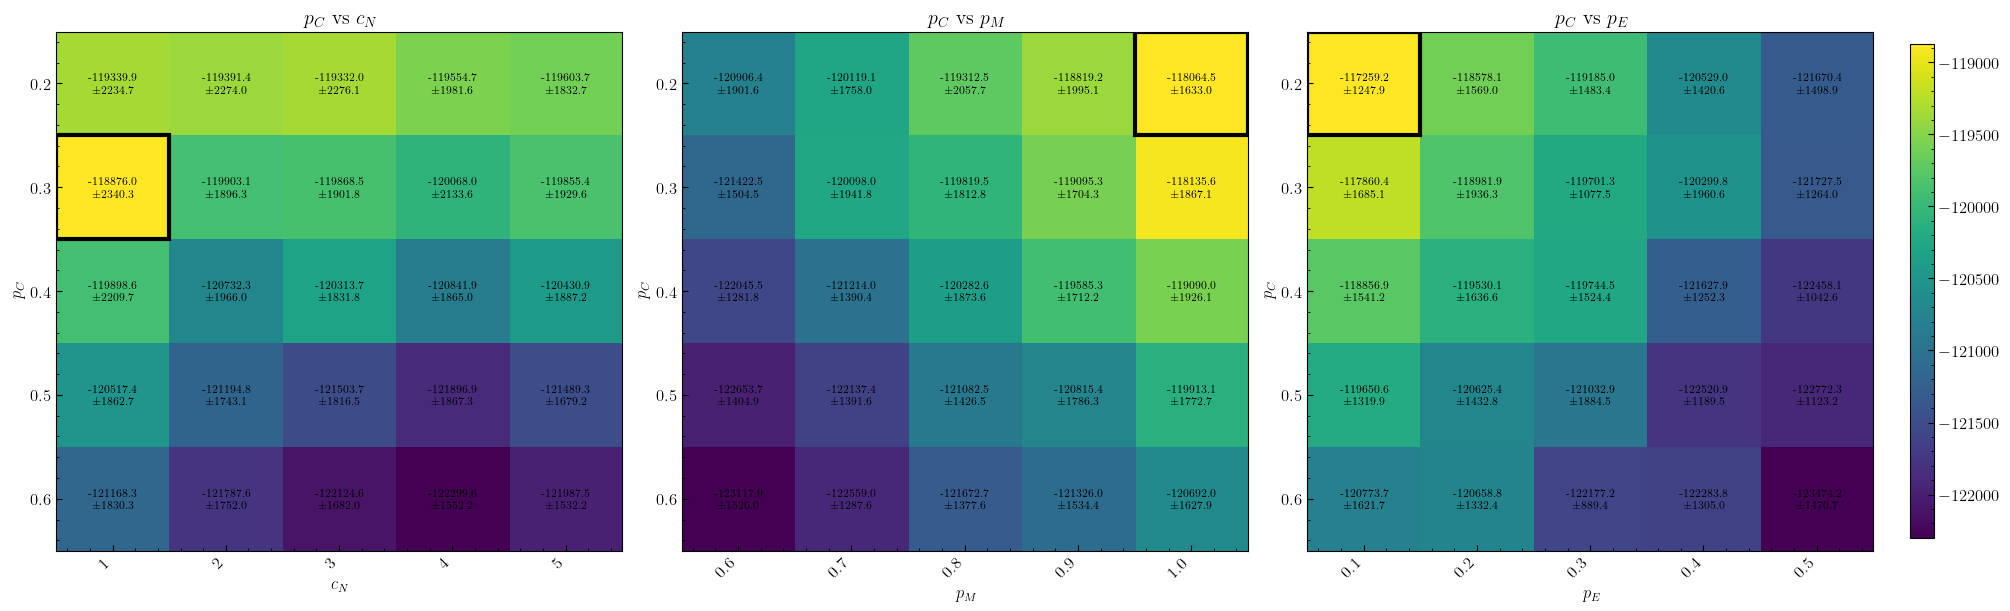

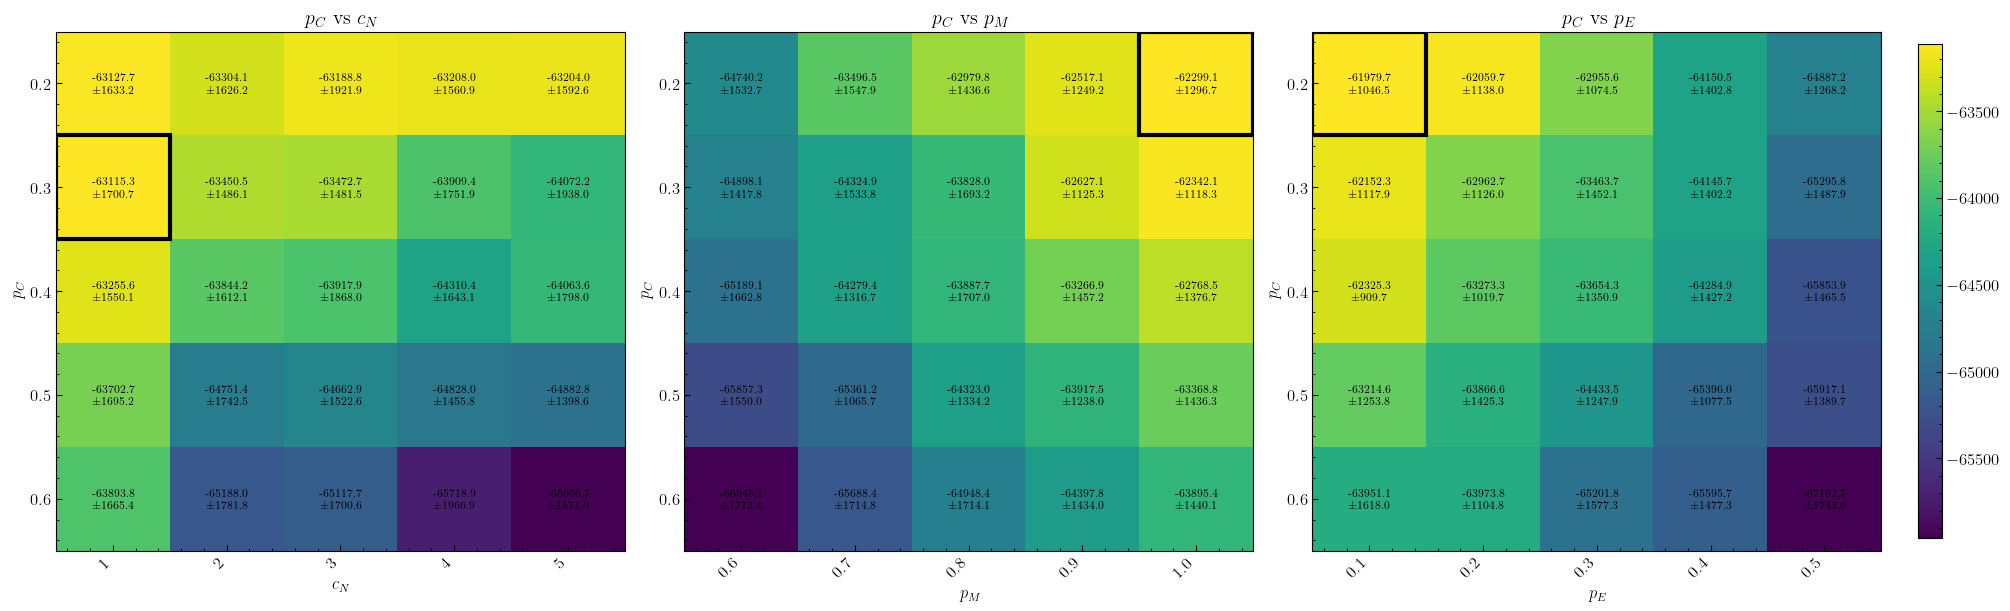

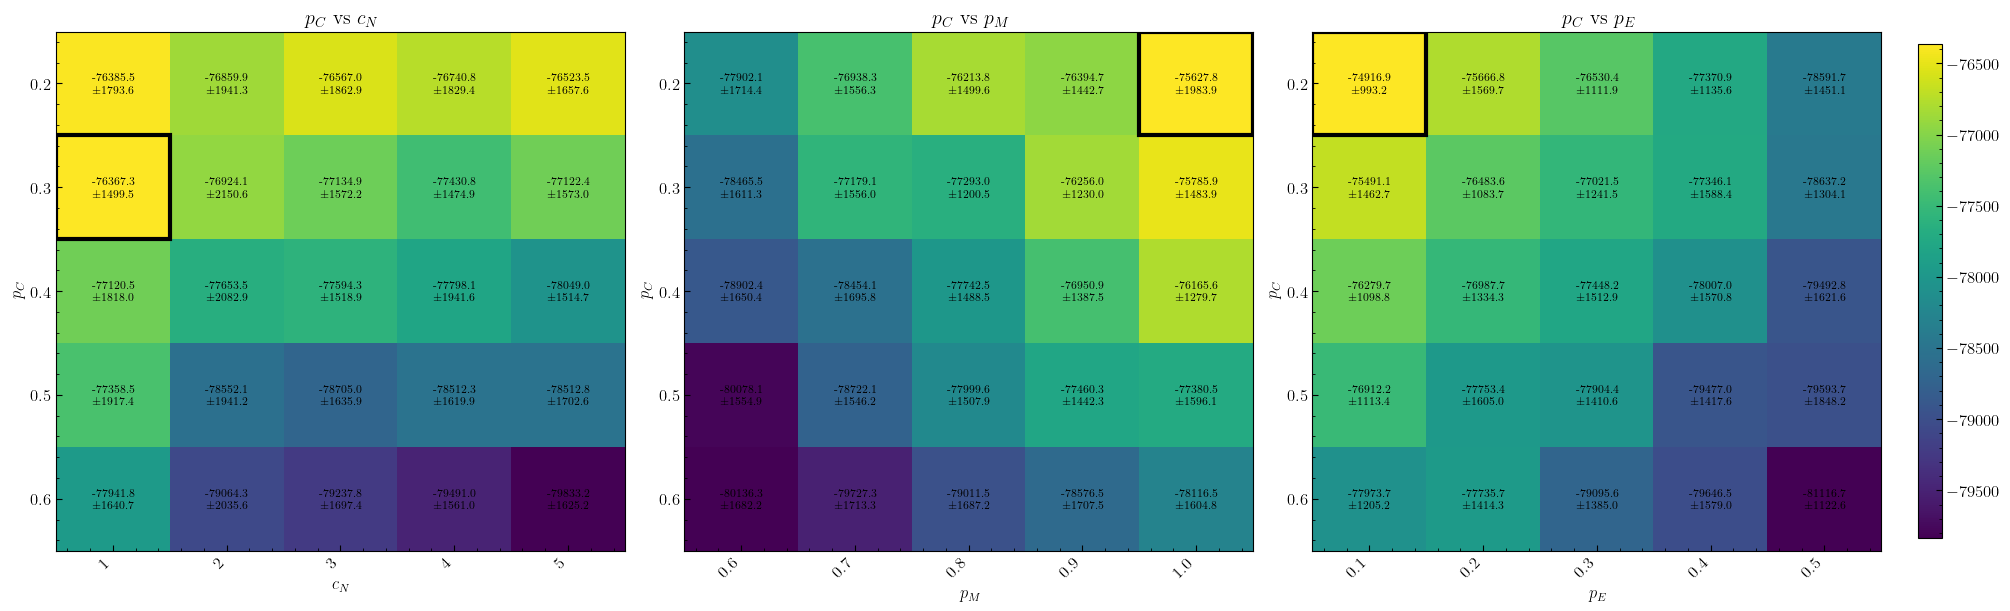

In [34]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


families = {
    "ER": os.path.join(base, "sweep_agg_er.csv"),
    "BA": os.path.join(base, "sweep_agg_ba.csv"),
    "WS": os.path.join(base, "sweep_agg_ws.csv"),
}

params = [
    "crossover_proportion",
    "crossover_edges",
    "mutation_prob",
    "elitism_proportion",
]

pretty = {
    "crossover_proportion": r"$p_C$",
    "crossover_edges": r"$c_N$",
    "mutation_prob": r"$p_M$",
    "elitism_proportion": r"$p_E$",
}


def sorted_unique(vals):
    return sorted(pd.Series(vals).dropna().unique().tolist())


def build_pairwise_pivots(df, row_param, col_param):
    """
    Collapse over the other two hyperparameters.

    cell_mean = average of df['mean'] over all remaining settings
    cell_std  = std of df['mean'] over all remaining settings

    So ± here reflects variability across the omitted hyperparameters.
    """
    grouped = (
        df.groupby([row_param, col_param])["mean"]
        .agg(cell_mean="mean", cell_std="std")
        .reset_index()
    )

    mean_pivot = grouped.pivot(index=row_param, columns=col_param, values="cell_mean")
    std_pivot = grouped.pivot(index=row_param, columns=col_param, values="cell_std")

    # enforce sorted numeric ordering
    row_order = sorted_unique(df[row_param])
    col_order = sorted_unique(df[col_param])

    mean_pivot = mean_pivot.reindex(index=row_order, columns=col_order)
    std_pivot = std_pivot.reindex(index=row_order, columns=col_order)

    return mean_pivot, std_pivot


def draw_one_heatmap(ax, mean_pivot, std_pivot, row_param, col_param, title):
    values = mean_pivot.values.astype(float)
    im = ax.imshow(values, aspect="auto")

    ax.set_xticks(range(len(mean_pivot.columns)))
    ax.set_xticklabels([str(x) for x in mean_pivot.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(mean_pivot.index)))
    ax.set_yticklabels([str(y) for y in mean_pivot.index])

    ax.set_xlabel(pretty[col_param])
    ax.set_ylabel(pretty[row_param])
    ax.set_title(title)

    # annotate mean ± std
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            m = mean_pivot.iloc[i, j]
            s = std_pivot.iloc[i, j]

            if pd.isna(m):
                label = ""
            elif pd.isna(s):
                label = f"{m:.1f}"
            else:
                label = f"{m:.1f}\n±{s:.1f}"

            ax.text(j, i, label, ha="center", va="center", fontsize=8)

    # highlight best cell in this heatmap
    if np.isfinite(values).any():
        best_flat = np.nanargmax(values)
        best_i, best_j = np.unravel_index(best_flat, values.shape)
        ax.add_patch(Rectangle((best_j - 0.5, best_i - 0.5), 1, 1, fill=False, linewidth=3))
        # ax.text(best_j, best_i - 0.38, "BEST", ha="center", va="bottom", fontsize=8)

    return im

def plot_family_pairwise_heatmaps(df, family_name, outfile=None):
    pair_list = list(itertools.combinations(params, 2))

    fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
    axes = axes.flatten()

    ims = []
    for ax, (p1, p2) in zip(axes, pair_list):
        mean_pivot, std_pivot = build_pairwise_pivots(df, row_param=p1, col_param=p2)

        im = draw_one_heatmap(
            ax,
            mean_pivot,
            std_pivot,
            row_param=p1,
            col_param=p2,
            title=f"{pretty[p1]} vs {pretty[p2]}",
        )
        ims.append(im)

    cbar = fig.colorbar(ims[0], ax=axes, shrink=0.95, pad=0.02)
    # cbar.set_label("Average score across remaining configurations")

    # fig.suptitle(
    #     f"{family_name}: pairwise hyperparameter heatmaps\n"
    #     f"(cell = mean score ± SD across collapsed settings)",
    #     fontsize=14,
    # )

    if outfile is not None:
        plt.savefig(outfile, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

for fam, path in families.items():
    df = pd.read_csv(path)
    plot_family_pairwise_heatmaps(
        df,
        family_name=fam,
        outfile=os.path.join(base, f"{fam.lower()}_pairwise_heatmaps.png"),
    )